In [162]:
# base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (log_loss, average_precision_score,
                             precision_score, recall_score,
                             roc_auc_score, f1_score,
                             roc_curve, precision_recall_curve,
                             brier_score_loss, confusion_matrix,
                             fbeta_score, classification_report)

# Calibration
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator

# Utilities
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split,
                                     GridSearchCV, StratifiedKFold,
                                     cross_val_score)
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import shap
import joblib
import optuna
import warnings


# Hide useless logs
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings(
    'ignore',
    message='Found unknown categories.*',
    category=UserWarning
)

In [69]:
# Constants
RANDOM_SEED = 42
PATH_TO_TRAIN_DATA = '../data/train-FIN_ANA_DATA.xls'
PATH_TO_TEST_DATA = '../data/test-FIN_ANA_DATA.xls'

In [70]:
df_train = pd.read_excel(PATH_TO_TRAIN_DATA)
df_test= pd.read_excel(PATH_TO_TEST_DATA)

In [71]:
# keep only train classes in test target value
known_classes = df_train['QUALITY_OF_LOAN'].unique()
df_test = df_test[df_test['QUALITY_OF_LOAN'].isin(known_classes)]

# Target value encoding
mapping = {"G": 0, "B": 1}
df_train['QUALITY_OF_LOAN'] = df_train["QUALITY_OF_LOAN"].map(mapping)
df_test['QUALITY_OF_LOAN'] = df_test["QUALITY_OF_LOAN"].map(mapping)

In [72]:
X = df_train.drop(columns=['QUALITY_OF_LOAN', 'ACC_NO'])
y = df_train['QUALITY_OF_LOAN']

X_test = df_test.drop(columns=['QUALITY_OF_LOAN', 'ACC_NO'])
y_test = df_test['QUALITY_OF_LOAN']

In [73]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3,
                                                    stratify=y, random_state=RANDOM_SEED)
X_val, X_cal, y_val, y_cal = train_test_split(X_temp, y_temp, test_size=0.33,
                                              stratify=y_temp, random_state=RANDOM_SEED)

print(f"Train DataFrame length is {X_train.shape[0]} ({X_train.shape[0] / df_train.shape[0] * 100:.1f}%)")
print(f"Validation DataFrame length is {X_val.shape[0]} ({X_val.shape[0] / df_train.shape[0] * 100:.1f}%)")
print(f"Calibration Dataframe length is {X_cal.shape[0]} ({X_cal.shape[0] / df_train.shape[0] * 100:.1f}%)")
print(f"Test DataFrame length is {X_test.shape[0]}")

Train DataFrame length is 26185 (70.0%)
Validation DataFrame length is 7519 (20.1%)
Calibration Dataframe length is 3704 (9.9%)
Test DataFrame length is 4305


In [112]:
def target_stats(name, y):
    print(
        f'{name:12s}: '
        f'n={len(y):5d}, '
        f'positive={y.sum():4d}, '
        f'positive_rate={y.mean():.4%}'
    )


target_stats('train', y_train)
target_stats('validation', y_val)
target_stats('calibration', y_cal)
target_stats('test', y_test)

train       : n=26185, positive=2908, positive_rate=11.1056%
validation  : n= 7519, positive= 835, positive_rate=11.1052%
calibration : n= 3704, positive= 411, positive_rate=11.0961%
test        : n= 4305, positive=  19, positive_rate=0.4413%


**Test set represents a substantially different population/distribution than the development dataset**

In [7]:
categorial_features = ['INF_MARITAL_STATUS', 'INF_GENDER',
                       'COMPENSATION_CHARGED', 'CLIENT_TYPE',
                       'REPAY_MODE']
numeric_features = ['INVESTMENT_TOTAL', 'ACCCURRENTBALANCE',
                    'INSTALL_SIZE', 'DUE_PAYMENT']

In [8]:
# LOGISTIC REGRESSION

# Numeric features preprocessing
numeric_pipeline_logreg = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=-1)),
    ('scaler', RobustScaler())
])

# Categorial features preprocessing
categorial_pipeline_logreg = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('zero_imputer', SimpleImputer(missing_values=0, strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(
        drop='first',
        handle_unknown='infrequent_if_exist',
        min_frequency=0.01,
        sparse_output=False))
])

log_reg_transformer = ColumnTransformer(transformers=[
    ('numeric', numeric_pipeline_logreg, numeric_features),
    ('categorical', categorial_pipeline_logreg, categorial_features)
])

# Logistic Regression Pipeline
logreg_pipe = Pipeline(steps=[
    ('log_reg_transformer', log_reg_transformer),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_SEED))
])

In [9]:
# XGBOOST

# Numeric features preprocessing
numeric_pipeline_xgb = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=-1))
])

# Categorial features preprocessing
categorial_pipeline_xgb = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('zero_imputer', SimpleImputer(missing_values=0, strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


xgb_transformer = ColumnTransformer(transformers=[
    ('numeric', numeric_pipeline_xgb, numeric_features),
    ('categorical', categorial_pipeline_xgb, categorial_features)
])

# XGBoost Pipeline
xgb_pipeline = Pipeline(steps=[
    ('xgb_transformer', xgb_transformer),
    ('model', XGBClassifier(
        random_state=RANDOM_SEED))
])

In [10]:
# CATBOOST

# Numeric features preprocessing
numeric_pipeline_catboost = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=-1))
])

# Categorial features preprocessing
categorial_pipeline_catboost = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('zero_imputer', SimpleImputer(missing_values=0, strategy='constant', fill_value='missing'))
])

catboost_transformer = ColumnTransformer(transformers=[
    ('numeric', numeric_pipeline_catboost, numeric_features),
    ('categorical', categorial_pipeline_catboost, categorial_features)
])

cat_features_indices = list(
    range(
        len(numeric_features),
        len(numeric_features) + len(categorial_features)
    )
)

# Catboost Pipeline
catboost_pipeline = Pipeline(steps=[
    ('catboost_transformer', catboost_transformer),
    ('model', CatBoostClassifier(random_state=RANDOM_SEED,
                                 cat_features=cat_features_indices,
                                 verbose=False))
])

In [11]:
metrics_table = pd.DataFrame(
    columns=['Model', 'Precision', 'Recall',
             'F1', 'Logloss', 'PR-AUC', 'ROC-AUC']
)

# Logistic Regression
logreg_pipe.fit(X_train, y_train)
y_proba_logreg_val = logreg_pipe.predict_proba(X_val)[:, 1]
y_pred_logreg_val = (y_proba_logreg_val >= 0.5).astype(int)
metrics_table.loc[len(metrics_table)] = [
    'Logistic Regression (base)',
    round(precision_score(y_val, y_pred_logreg_val), 3),
    round(recall_score(y_val, y_pred_logreg_val), 3),
    round(f1_score(y_val, y_pred_logreg_val), 3),
    round(log_loss(y_val, y_proba_logreg_val), 3),
    round(average_precision_score(y_val, y_proba_logreg_val), 3),
    round(roc_auc_score(y_val, y_proba_logreg_val), 3)
]

# XGBoost
xgb_pipeline.fit(X_train, y_train)
y_proba_xgb_val = xgb_pipeline.predict_proba(X_val)[:, 1]
y_pred_xgb_val = (y_proba_xgb_val >= 0.5).astype(int)
metrics_table.loc[len(metrics_table)] = [
    'XGBoost (base)',
    round(precision_score(y_val, y_pred_xgb_val), 3),
    round(recall_score(y_val, y_pred_xgb_val), 3),
    round(f1_score(y_val, y_pred_xgb_val), 3),
    round(log_loss(y_val, y_proba_xgb_val), 3),
    round(average_precision_score(y_val, y_proba_xgb_val), 3),
    round(roc_auc_score(y_val, y_proba_xgb_val), 3)
]

# Catboost
catboost_pipeline.fit(X_train, y_train)
y_proba_catboost_val = catboost_pipeline.predict_proba(X_val)[:, 1]
y_pred_catboost_val = (y_proba_catboost_val >= 0.5).astype(int)
metrics_table.loc[len(metrics_table)] = [
    'Catboost (base)',
    round(precision_score(y_val, y_pred_catboost_val), 3),
    round(recall_score(y_val, y_pred_catboost_val), 3),
    round(f1_score(y_val, y_pred_catboost_val), 3),
    round(log_loss(y_val, y_proba_catboost_val), 3),
    round(average_precision_score(y_val, y_proba_catboost_val), 3),
    round(roc_auc_score(y_val, y_proba_catboost_val), 3)
]

metrics_table

,Model,Precision,Recall,F1,Logloss,PR-AUC,ROC-AUC
0,Logistic Regression (base),0.165,0.662,0.264,0.659,0.187,0.663
1,XGBoost (base),0.729,0.174,0.280,0.280,0.437,0.793
2,Catboost (base),0.844,0.097,0.174,0.288,0.414,0.781


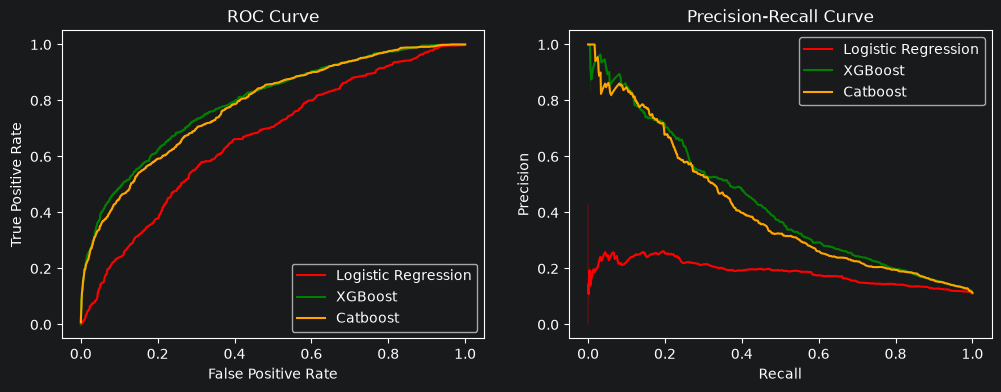

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
(ax1, ax2) = axes.flatten()

# ROC Curve
fpr_logreg, tpr_logreg, _ = roc_curve(y_val, y_proba_logreg_val)
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_proba_xgb_val)
fpr_catboost, tpr_catboost, _ = roc_curve(y_val, y_proba_catboost_val)

sns.lineplot(x=fpr_logreg, y=tpr_logreg, ax=ax1, color='red', label='Logistic Regression')
sns.lineplot(x=fpr_xgb, y=tpr_xgb, ax=ax1, color='green', label='XGBoost')
sns.lineplot(x=fpr_catboost, y=tpr_catboost, ax=ax1, color='orange', label='Catboost')
ax1.set_title('ROC Curve')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc='lower right')


# PR Curve
precision_logreg, recall_logreg, _ = precision_recall_curve(
    y_val, y_proba_logreg_val
)
precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_val, y_proba_xgb_val
)
precision_catboost, recall_catboost, _ = precision_recall_curve(
    y_val, y_proba_catboost_val
)

sns.lineplot(x=recall_logreg, y=precision_logreg, ax=ax2, color='red', label='Logistic Regression')
sns.lineplot(x=recall_xgb, y=precision_xgb, ax=ax2, color='green', label='XGBoost')
sns.lineplot(x=recall_catboost, y=precision_catboost, ax=ax2, color='orange', label='Catboost')
ax2.set_title('Precision-Recall Curve')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc='upper right')

plt.show()

## Hyperparameter tuning

In [13]:
# LOGISTIC REGRESSION
param_grid = [
    {
        'model__solver': ['liblinear'],
        'model__l1_ratio': [0, 1],
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__class_weight': [None, 'balanced']
    },
    {
        'model__solver': ['lbfgs'],
        'model__l1_ratio': [0],
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__class_weight': [None, 'balanced']
    },
    {
        'model__solver': ['saga'],
        'model__l1_ratio': [0, 0.25, 0.5, 0.75, 1],
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__class_weight': [None, 'balanced']
    }
]

grid_search = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=param_grid,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=5,
                       shuffle=True,
                       random_state=RANDOM_SEED),
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__C': [0.001, 0.01, ...], 'model__class_weight': [None, 'balanced'], 'model__l1_ratio': [0, 1], 'model__solver': ['liblinear']}, {'model__C': [0.001, 0.01, ...], 'model__class_weight': [None, 'balanced'], 'model__l1_ratio': [0], 'model__solver': ['lbfgs']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be 

In [17]:
# Fitted best Logistic Regression model
best_logreg = grid_search.best_estimator_

y_proba_logreg_val = best_logreg.predict_proba(X_val)[:, 1]
y_pred_logreg_val = (y_proba_logreg_val >= 0.5).astype(int)
metrics_table.loc[len(metrics_table)] = [
    'Logistic Regression (optimized)',
    round(precision_score(y_val, y_pred_logreg_val), 3),
    round(recall_score(y_val, y_pred_logreg_val), 3),
    round(f1_score(y_val, y_pred_logreg_val), 3),
    round(log_loss(y_val, y_proba_logreg_val), 3),
    round(average_precision_score(y_val, y_proba_logreg_val), 3),
    round(roc_auc_score(y_val, y_proba_logreg_val), 3)
]

In [19]:
# XGBOOST
def objective_xgb(trial_xgb):

    params = {
        'model__n_estimators': trial_xgb.suggest_int(
            'n_estimators', 100, 800
        ),
        'model__max_depth': trial_xgb.suggest_int(
            'max_depth', 3, 10
        ),
        'model__learning_rate': trial_xgb.suggest_float(
            'learning_rate', 0.01, 0.3, log=True
        ),
        'model__subsample': trial_xgb.suggest_float(
            'subsample', 0.6, 1.0
        ),
        'model__colsample_bytree': trial_xgb.suggest_float(
            'colsample_bytree', 0.6, 1.0
        ),
        'model__min_child_weight': trial_xgb.suggest_int(
            'min_child_weight', 1, 20
        ),
        'model__gamma': trial_xgb.suggest_float(
            'gamma', 0.0, 5.0
        ),
        'model__reg_alpha': trial_xgb.suggest_float(
            'reg_alpha', 1e-8, 10.0, log=True
        ),
        'model__reg_lambda': trial_xgb.suggest_float(
            'reg_lambda', 1e-8, 10.0, log=True
        )
    }

    pipeline = Pipeline(steps=[
        ('xgb_transformer', xgb_transformer),
        ('model', XGBClassifier(eval_metric='logloss',
                                random_state=RANDOM_SEED))
    ])
    pipeline.set_params(**params)

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_SEED
    )

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring='average_precision',
        n_jobs=-1
    )

    return scores.mean()

study_xgb = optuna.create_study(direction='maximize')

study_xgb.optimize(
    objective_xgb,
    n_trials=50
)

In [20]:
best_xgb = Pipeline(steps=[
    ('xgb_transformer', xgb_transformer),
    ('model', XGBClassifier(
        **study_xgb.best_params,
        random_state=RANDOM_SEED
    ))
])

best_xgb.fit(X_train, y_train)
y_proba_xgb_val = best_xgb.predict_proba(X_val)[:, 1]
y_pred_xgb_val = (y_proba_xgb_val >= 0.5).astype(int)
metrics_table.loc[len(metrics_table)] = [
    'XGBoost (optimized)',
    round(precision_score(y_val, y_pred_xgb_val), 3),
    round(recall_score(y_val, y_pred_xgb_val), 3),
    round(f1_score(y_val, y_pred_xgb_val), 3),
    round(log_loss(y_val, y_proba_xgb_val), 3),
    round(average_precision_score(y_val, y_proba_xgb_val), 3),
    round(roc_auc_score(y_val, y_proba_xgb_val), 3)
]

In [21]:
def objective_catboost(trial):

    params = {
        'iterations': trial.suggest_int(
            'iterations', 200, 800
        ),
        'depth': trial.suggest_int(
            'depth', 4, 8
        ),
        'learning_rate': trial.suggest_float(
            'learning_rate', 0.01, 0.2, log=True
        ),
        'l2_leaf_reg': trial.suggest_float(
            'l2_leaf_reg', 1e-2, 20.0, log=True
        ),
        'random_strength': trial.suggest_float(
            'random_strength', 0.0, 5.0
        ),
        'bagging_temperature': trial.suggest_float(
            'bagging_temperature', 0.0, 5.0
        ),
        'border_count': trial.suggest_int(
            'border_count', 32, 255
        )
    }

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_SEED
    )

    scores = []

    for fold, (train_idx, valid_idx) in enumerate(
        cv.split(X_train, y_train)
    ):

        X_fold_train = X_train.iloc[train_idx]
        X_fold_valid = X_train.iloc[valid_idx]

        y_fold_train = y_train.iloc[train_idx]
        y_fold_valid = y_train.iloc[valid_idx]

        transformer = clone(catboost_transformer)

        X_fold_train_transformed = transformer.fit_transform(
            X_fold_train
        )

        X_fold_valid_transformed = transformer.transform(
            X_fold_valid
        )

        model = CatBoostClassifier(
            **params,
            cat_features=cat_features_indices,
            random_seed=RANDOM_SEED,
            verbose=False
        )

        model.fit(
            X_fold_train_transformed,
            y_fold_train,
            eval_set=(
                X_fold_valid_transformed,
                y_fold_valid
            ),
            early_stopping_rounds=100,
            verbose=False
        )

        y_proba = model.predict_proba(
            X_fold_valid_transformed
        )[:, 1]

        score = average_precision_score(
            y_fold_valid,
            y_proba
        )

        scores.append(score)

        # pruning
        mean_score = np.mean(scores)
        trial.report(
            mean_score,
            step=fold
        )

        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(scores)


pruner = optuna.pruners.MedianPruner(
    n_startup_trials=5,
    n_warmup_steps=1
)

study_catboost = optuna.create_study(
    direction='maximize',
    pruner=pruner
)


# Works too long
study_catboost.optimize(
    objective_catboost,
    n_trials=20
)

In [25]:
best_catboost = Pipeline(steps=[
    ('catboost_transformer', catboost_transformer),
    ('model', CatBoostClassifier(
        **study_catboost.best_params,
        cat_features=cat_features_indices,
        random_state=RANDOM_SEED,
        verbose=False
    ))
])

best_catboost.fit(X_train, y_train)
y_proba_catboost_val = best_catboost.predict_proba(X_val)[:, 1]
y_pred_catboost_val = (y_proba_catboost_val >= 0.5).astype(int)
metrics_table.loc[len(metrics_table)] = [
    'Catboost (optimized)',
    round(precision_score(y_val, y_pred_catboost_val), 3),
    round(recall_score(y_val, y_pred_catboost_val), 3),
    round(f1_score(y_val, y_pred_catboost_val), 3),
    round(log_loss(y_val, y_proba_catboost_val), 3),
    round(average_precision_score(y_val, y_proba_catboost_val), 3),
    round(roc_auc_score(y_val, y_proba_catboost_val), 3)
]

In [26]:
metrics_table

,Model,Precision,Recall,F1,Logloss,PR-AUC,ROC-AUC
0,Logistic Regression (base),0.165,0.662,0.264,0.659,0.187,0.663
1,XGBoost (base),0.729,0.174,0.280,0.280,0.437,0.793
2,Catboost (base),0.844,0.097,0.174,0.288,0.414,0.781
3,Logistic Regression (optimized),0.000,0.000,0.000,0.329,0.198,0.677
4,XGBoost (optimized),0.613,0.317,0.418,0.302,0.459,0.796
5,Catboost (optimized),0.770,0.193,0.308,0.274,0.466,0.805


### The best model based on the Precision-Recall metric is Catboost

Metrics of the Catboost model are:
- Precision: 0.77
- Recall: 0.193
- F1: 0.308
- Logloss: 0.274
- PR-AUC: 0.466
- ROC-AUC: 0.805

## Calibration

In [28]:
# Training model on train + val sets
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

best_catboost.fit(X_train_final, y_train_final)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('catboost_transformer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['INVESTMENT_TOTAL','ACCCURRENTBALANCE','INF_MARITAL_STATUS',..., 'COMPENSATION_CHARGED','CLIENT_TYPE','REPAY_MODE']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default

In [29]:
calibrated_pipe_isotonic = CalibratedClassifierCV(
    estimator=FrozenEstimator(best_catboost),
    method='isotonic'
)

calibrated_pipe_sigmoid = CalibratedClassifierCV(
    estimator=FrozenEstimator(best_catboost),
    method='sigmoid'
)

calibrated_pipe_isotonic.fit(X_cal, y_cal)
calibrated_pipe_sigmoid.fit(X_cal, y_cal)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",FrozenEstimat...ose=False))]))
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,[<sklearn.cali...001CCF89D6480>]
"

In [30]:
# prediction
y_proba_raw = best_catboost.predict_proba(X_cal)[:, 1]
y_proba_with_isotonic = calibrated_pipe_isotonic.predict_proba(X_cal)[:, 1]
y_proba_with_sigmoid = calibrated_pipe_sigmoid.predict_proba(X_cal)[:, 1]

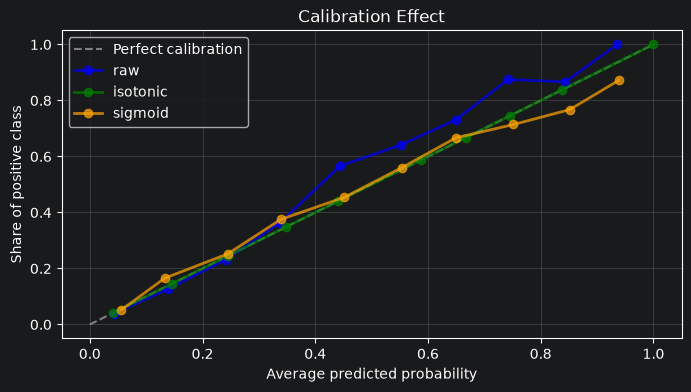

In [31]:
# Calibration graph

fop_orig_raw, mpv_orig_raw = calibration_curve(y_cal, y_proba_raw,
                                               n_bins=10)

fop_orig_isotonic, mpv_orig_isotonic = calibration_curve(y_cal, y_proba_with_isotonic,
                                                             n_bins=10)

fop_orig_sigmoid, mpv_orig_sigmoid = calibration_curve(y_cal, y_proba_with_sigmoid,
                                                             n_bins=10)

display_setup = ['blue', 'green', 'orange']

plt.figure(figsize=(8, 4))
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
plt.plot(mpv_orig_raw, fop_orig_raw, marker='o', linewidth=2,
         label='raw', alpha=0.7, color=display_setup[0])
plt.plot(mpv_orig_isotonic, fop_orig_isotonic, marker='o', linewidth=2,
         label='isotonic', alpha=0.7, color=display_setup[1])
plt.plot(mpv_orig_sigmoid, fop_orig_sigmoid, marker='o', linewidth=2,
         label='sigmoid', alpha=0.7, color=display_setup[2])

plt.title('Calibration Effect')
plt.xlabel('Average predicted probability')
plt.ylabel('Share of positive class')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [32]:
# Brier score
brier_raw = brier_score_loss(y_cal, y_proba_raw)
brier_isotonic = brier_score_loss(y_cal, y_proba_with_isotonic)
brier_sigmoid = brier_score_loss(y_cal, y_proba_with_sigmoid)

print(f"Brier score (raw): {brier_raw:.4f}")
print(f"Brier score (isotonic): {brier_isotonic:.4f}")
print(f"Brier score (sigmoid): {brier_sigmoid:.4f}")

Brier score (raw): 0.0742
Brier score (isotonic): 0.0725
Brier score (sigmoid): 0.0742


## Searching for a classification threshold

In [113]:
def threshold_searching(y_true, y_proba):
    unique_thresholds = np.linspace(0, 1, 1001)

    best_fB = -np.inf

    for threshold in unique_thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        # more wight to recall (beta=2)
        fB = fbeta_score(y_true, y_pred, beta=2)

        if fB > best_fB:
            best_fB = fB
            best_threshold = threshold

    print(f"Best threshold: {best_threshold:.4f}")
    print(f"Best fB: {best_fB:.4f}")
    return best_threshold

In [114]:
best_threshold = threshold_searching(y_cal, y_proba_with_isotonic)
y_pred_threshold = (y_proba_with_isotonic >= best_threshold).astype(int)

Best threshold: 0.0750
Best fB: 0.5558


In [115]:
print(f"Metrics with threshold {best_threshold:.4f}:")
print(f"Precision: {precision_score(y_cal, y_pred_threshold):.3f}")
print(f"Recall: {recall_score(y_cal, y_pred_threshold):.3f}")
print(f"F1: {f1_score(y_cal, y_pred_threshold):.3f}")
print(f"Logloss: {log_loss(y_cal, y_proba_with_isotonic):.3f}")
print(f"PR: {average_precision_score(y_cal, y_proba_with_isotonic):.3f}")
print(f"ROC: {roc_auc_score(y_cal, y_proba_with_isotonic):.3f}")

Metrics with threshold 0.0750:
Precision: 0.276
Recall: 0.745
F1: 0.403
Logloss: 0.254
PR: 0.488
ROC: 0.830


In [116]:
print(classification_report(y_cal, y_pred_threshold))

              precision    recall  f1-score   support

           0       0.96      0.76      0.85      3293
           1       0.28      0.74      0.40       411

    accuracy                           0.75      3704
   macro avg       0.62      0.75      0.62      3704
weighted avg       0.88      0.75      0.80      3704



## Test set

In [117]:
y_proba_test = calibrated_pipe_isotonic.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= best_threshold).astype(int)

In [118]:
print(f"Metrics on the test set:")
print(f"Precision: {precision_score(y_test, y_pred_test):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_test):.3f}")
print(f"F1: {f1_score(y_test, y_pred_test):.3f}")
print(f"Logloss: {log_loss(y_test, y_proba_test):.3f}")
print(f"PR: {average_precision_score(y_test, y_proba_test):.3f}")
print(f"ROC: {roc_auc_score(y_test, y_proba_test):.3f}")

Metrics on the test set:
Precision: 0.012
Recall: 0.368
F1: 0.023
Logloss: 0.071
PR: 0.022
ROC: 0.630


In [119]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      0.86      0.92      4286
           1       0.01      0.37      0.02        19

    accuracy                           0.86      4305
   macro avg       0.50      0.62      0.47      4305
weighted avg       0.99      0.86      0.92      4305



On the test set all metrics are significantly less than before

## Classification Matrix

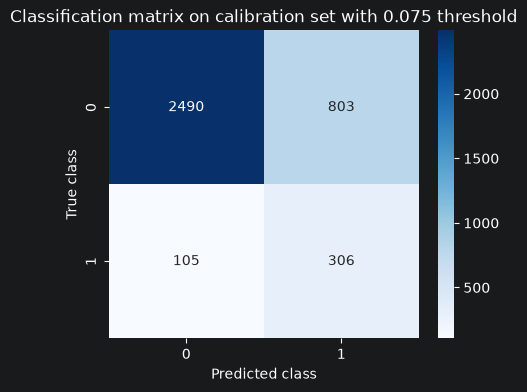

In [127]:
# Calibration set
cm = confusion_matrix(y_cal, y_pred_threshold)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title(f'Classification matrix on calibration set with {best_threshold:.3f} threshold')
plt.show()

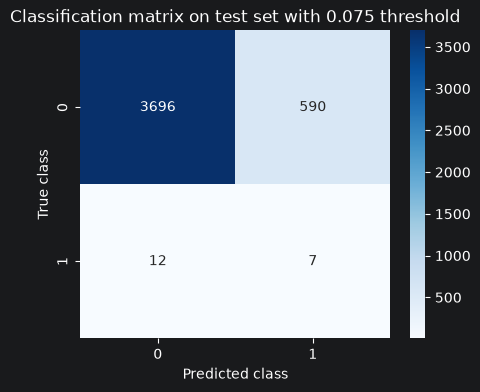

In [128]:
# Test set
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title(f'Classification matrix on test set with {best_threshold:.3f} threshold')
plt.show()

## Feature importance

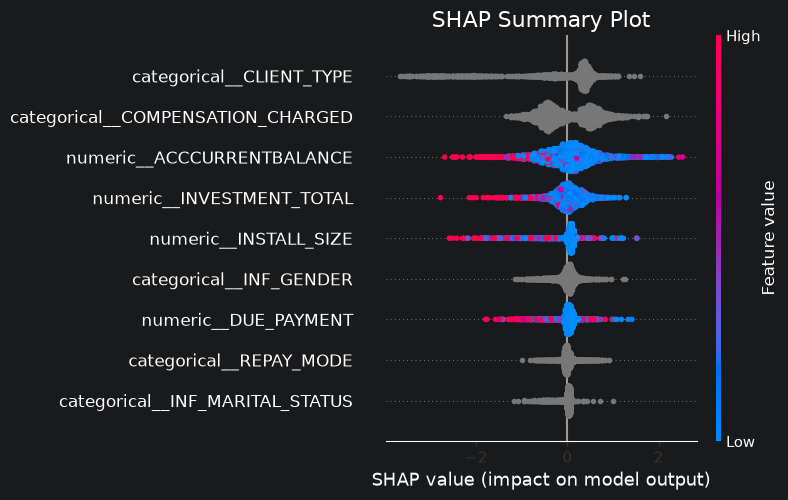

In [161]:
def shap_plot(model):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(catboost_transformer.transform(X_cal))

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values,
                      catboost_transformer.transform(X_cal),
                      feature_names=catboost_transformer.get_feature_names_out(),
                      show=False)

    ax = plt.gca()
    ax.set_yticklabels(ax.get_yticklabels(), color='white', fontsize=12)

    plt.title(f"SHAP Summary Plot", fontsize=16)
    plt.tight_layout()
    plt.show()

shap_plot(calibrated_pipe_isotonic.estimator.estimator.named_steps['model'])

## Model saving

In [171]:
joblib.dump(calibrated_pipe_isotonic, "../models/catboost_model.joblib")

['../models/catboost_model.joblib']